In [4]:
## Lecture 1

import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_state_qsphere

[0.        +0.j 0.70710678+0.j 0.70710678+0.j 0.        +0.j]


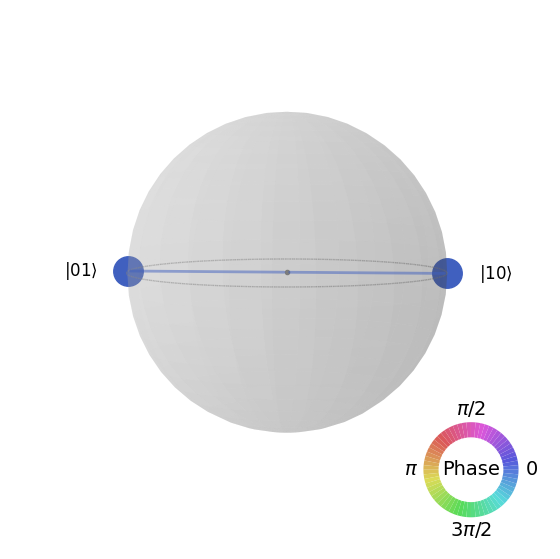

In [5]:
n = 2
qc = QuantumCircuit(n)
# Apply the Hadamard Gate
qc.h(0)
# Apply the CNOT Gate
qc.cx(0,1)
qc.x(1)
statevec = Statevector.from_instruction(qc).data
print(statevec)
plot_state_qsphere(statevec)

In [6]:
qc.draw()

┌───┐          
q_0: ┤ H ├──■───────
     └───┘┌─┴─┐┌───┐
q_1: ─────┤ X ├┤ X ├
          └───┘└───┘

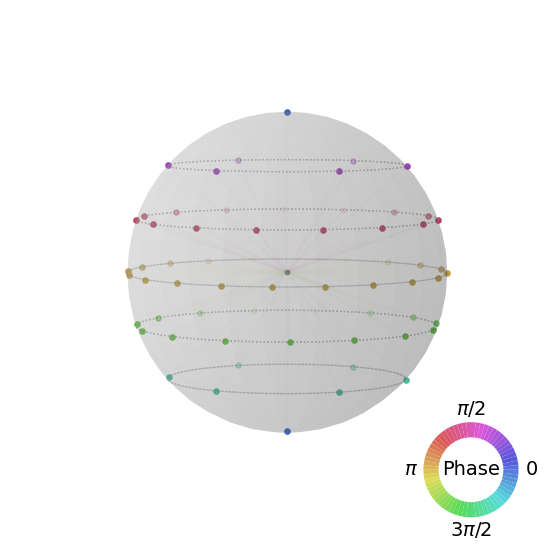

In [7]:
n = 6
qc1 = QuantumCircuit(n)
for i in range(n):
    qc1.h(i)
    qc1.rz(2*np.pi/n, i)
statevec = Statevector.from_instruction(qc1).data
plot_state_qsphere(statevec, show_state_labels=False)

In [8]:
qc1.draw()

┌───┐┌─────────┐
q_0: ┤ H ├┤ Rz(π/3) ├
     ├───┤├─────────┤
q_1: ┤ H ├┤ Rz(π/3) ├
     ├───┤├─────────┤
q_2: ┤ H ├┤ Rz(π/3) ├
     ├───┤├─────────┤
q_3: ┤ H ├┤ Rz(π/3) ├
     ├───┤├─────────┤
q_4: ┤ H ├┤ Rz(π/3) ├
     ├───┤├─────────┤
q_5: ┤ H ├┤ Rz(π/3) ├
     └───┘└─────────┘

In [9]:
## Lecture 5 — modern IBM Quantum version

from dotenv import load_dotenv
import os
import numpy as np

from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram
from qiskit_ibm_runtime import QiskitRuntimeService

load_dotenv()

token = os.getenv("IBM_QUANTUM_TOKEN")

# Run this once on your own laptop to save the token locally
QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token=token,
    overwrite=True
)

service = QiskitRuntimeService(channel="ibm_quantum_platform")
backend = service.least_busy(simulator=False, operational=True)

print(backend)

qiskit_runtime_service.__init__:WARNING:2026-03-29 18:05:28,294: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-03-29 18:05:29,219: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-03-29 18:05:33,940: Using instance: open-instance, plan: open


<IBMBackend('ibm_fez')>


In [10]:
def dj_oracle(case, n):
    oracle_qc = QuantumCircuit(n + 1)

    if case == "balanced":
        for qubit in range(n):
            oracle_qc.cx(qubit, n)

    elif case == "constant":
        output = np.random.randint(2)
        if output == 1:
            oracle_qc.x(n)

    oracle_gate = oracle_qc.to_gate()
    oracle_gate.name = "Oracle"
    return oracle_gate

In [11]:
def dj_algorithm(n, case = 'random'):
    # n+1 qubits and the n classical bits
    dj_circuit = QuantumCircuit(n+1,n)
    for qubit in range(n):
        dj_circuit.h(qubit)
    dj_circuit.x(n)
    dj_circuit.h(n)

    if case == 'random':
        random = np.random.randint(2)
        if random == 0:
            case = 'constant'
        else:
            case = 'balanced'
            
    oracle = dj_oracle(case,n)
    dj_circuit.append(oracle, range(n+1))

    for i in range(n):
        dj_circuit.h(i)
        dj_circuit.measure(i,i)
    return dj_circuit

In [12]:
n = 4
dj_circuit = dj_algorithm(n, 'balanced')
dj_circuit.draw()

┌───┐     ┌─────────┐┌───┐┌─┐         
q_0: ┤ H ├─────┤0        ├┤ H ├┤M├─────────
     ├───┤     │         │├───┤└╥┘┌─┐      
q_1: ┤ H ├─────┤1        ├┤ H ├─╫─┤M├──────
     ├───┤     │         │├───┤ ║ └╥┘┌─┐   
q_2: ┤ H ├─────┤2 Oracle ├┤ H ├─╫──╫─┤M├───
     ├───┤     │         │├───┤ ║  ║ └╥┘┌─┐
q_3: ┤ H ├─────┤3        ├┤ H ├─╫──╫──╫─┤M├
     ├───┤┌───┐│         │└───┘ ║  ║  ║ └╥┘
q_4: ┤ X ├┤ H ├┤4        ├──────╫──╫──╫──╫─
     └───┘└───┘└─────────┘      ║  ║  ║  ║ 
c: 4/═══════════════════════════╩══╩══╩══╩═
                                0  1  2  3

qiskit_runtime_service.__init__:WARNING:2026-03-29 18:05:37,853: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-03-29 18:05:38,444: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-03-29 18:05:42,351: Using instance: open-instance, plan: open


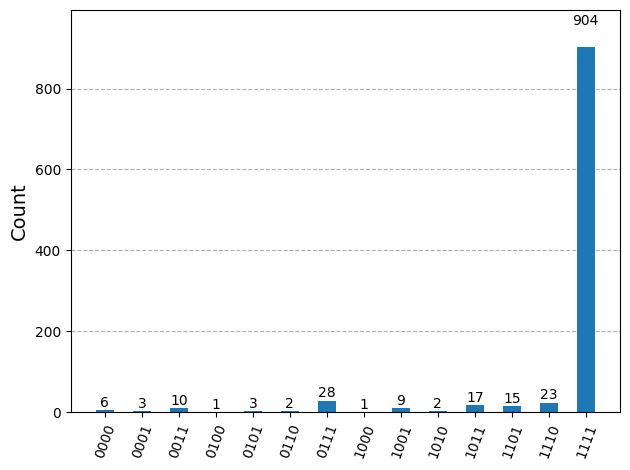

In [13]:
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
from qiskit.transpiler import generate_preset_pass_manager
from qiskit.visualization import plot_histogram

service = QiskitRuntimeService(channel="ibm_quantum_platform")
backend = service.least_busy(simulator=False, operational=True)

pm = generate_preset_pass_manager(backend=backend, optimization_level=3)
isa_circuit = pm.run(dj_circuit)

sampler = Sampler(mode=backend)
job = sampler.run([isa_circuit], shots=1024)
result = job.result()

counts = result[0].data.c.get_counts()
plot_histogram(counts)

In [25]:
# Lecture 6
from dotenv import load_dotenv
import os
import numpy as np

from qiskit import QuantumCircuit
from qiskit.quantum_info import Operator
from qiskit.visualization import plot_histogram
from qiskit_ibm_runtime import QiskitRuntimeService

def phase_oracle(n, indices_to_mark, name='Oracle'):
    qc = QuantumCircuit(n, name=name)
    oracle_matrix = np.identity(2**n)
    
    for index_to_mark in indices_to_mark:
        oracle_matrix[index_to_mark, index_to_mark] = -1
    
    qc.unitary(Operator(oracle_matrix), range(n))
    return qc


def diffuser(n):
    qc = QuantumCircuit(n, name='Diff - "V"')
    
    qc.h(range(n))
    qc.append(phase_oracle(n, [0]), range(n))
    qc.h(range(n))
    
    return qc

# We are jumping to work with M marked elements from the very beginning
def Grover(n, marked):
    qc = QuantumCircuit(n, n)
    
    r = int(np.round(np.pi / (4 * np.arcsin(np.sqrt(len(marked) / 2**n))) - 1/2))
    print(f'{n} qubits, basis state {marked} marked, {r} rounds')
    
    qc.h(range(n))
    
    for _ in range(r):
        qc.append(phase_oracle(n, marked), range(n))
        qc.append(diffuser(n), range(n))
    
    qc.measure(range(n), range(n))
    
    return qc

In [26]:
n = 5
x = np.random.randint(2**n)
marked = [x]
gr_circuit = Grover(n, marked)

gr_circuit.draw()

5 qubits, basis state [18] marked, 4 rounds


┌───┐┌─────────┐┌─────────────┐┌─────────┐┌─────────────┐┌─────────┐»
q_0: ┤ H ├┤0        ├┤0            ├┤0        ├┤0            ├┤0        ├»
     ├───┤│         ││             ││         ││             ││         │»
q_1: ┤ H ├┤1        ├┤1            ├┤1        ├┤1            ├┤1        ├»
     ├───┤│         ││             ││         ││             ││         │»
q_2: ┤ H ├┤2 Oracle ├┤2 Diff - "V" ├┤2 Oracle ├┤2 Diff - "V" ├┤2 Oracle ├»
     ├───┤│         ││             ││         ││             ││         │»
q_3: ┤ H ├┤3        ├┤3            ├┤3        ├┤3            ├┤3        ├»
     ├───┤│         ││             ││         ││             ││         │»
q_4: ┤ H ├┤4        ├┤4            ├┤4        ├┤4            ├┤4        ├»
     └───┘└─────────┘└─────────────┘└─────────┘└─────────────┘└─────────┘»
c: 5/════════════════════════════════════════════════════════════════════»
                                                                         »
«     ┌─────────────┐┌─────────┐┌─────────────┐┌─┐            
«q_0: ┤0            ├┤0        ├┤0            ├┤M├────────────
«     │             ││         ││             │└╥┘┌─┐         
«q_1: ┤1            ├┤1        ├┤1            ├─╫─┤M├─────────
«     │             ││         ││             │ ║ └╥┘┌─┐      
«q_2: ┤2 Diff - "V" ├┤2 Oracle ├┤2 Diff - "V" ├─╫──╫─┤M├──────
«     │             ││         ││             │ ║  ║ └╥┘┌─┐   
«q_3: ┤3            ├┤3        ├┤3            ├─╫──╫──╫─┤M├───
«     │             ││         ││             │ ║  ║  ║ └╥┘┌─┐
«q_4: ┤4            ├┤4        ├┤4            ├─╫──╫──╫──╫─┤M├
«     └─────────────┘└─────────┘└─────────────┘ ║  ║  ║  ║ └╥┘
«c: 5/══════════════════════════════════════════╩══╩══╩══╩══╩═
«                                               0  1  2  3  4

qiskit_runtime_service.__init__:WARNING:2026-03-29 18:18:48,866: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-03-29 18:18:49,427: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-03-29 18:18:54,162: Using instance: open-instance, plan: open


{'10111': 290, '00000': 354, '10101': 228, '10010': 1206, '10100': 280, '11010': 306, '00010': 540, '11100': 185, '01111': 238, '11000': 277, '01101': 193, '11111': 248, '11110': 276, '01010': 298, '00011': 367, '01011': 303, '11011': 299, '00001': 274, '01110': 240, '00100': 298, '10011': 430, '00111': 264, '01001': 248, '11101': 175, '10000': 394, '10001': 276, '10110': 343, '01100': 184, '00110': 369, '00101': 208, '11001': 197, '01000': 212}


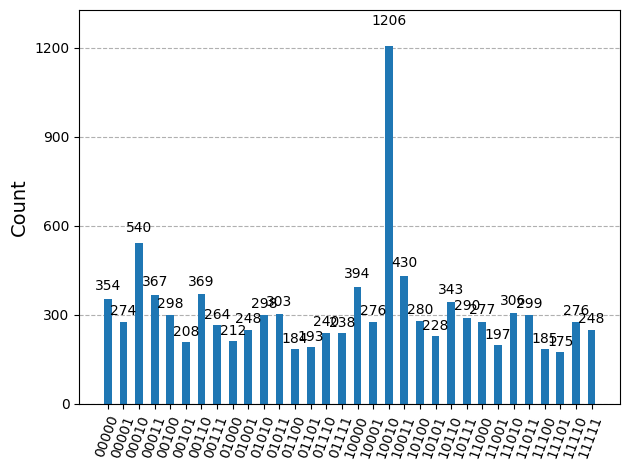

In [28]:
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
from qiskit.transpiler import generate_preset_pass_manager
from qiskit.visualization import plot_histogram

service = QiskitRuntimeService(channel="ibm_quantum_platform")
backend = service.least_busy(simulator=False, operational=True)

pm = generate_preset_pass_manager(backend=backend, optimization_level=3)
isa_circuit = pm.run(gr_circuit)

sampler = Sampler(mode=backend)
job = sampler.run([isa_circuit], shots=10000)
result = job.result()

counts_grover = result[0].data.c.get_counts()
print(counts_grover)
plot_histogram(counts_grover)